# 03 — Metastasis Prediction

**Scientific question:**
Do the resistance-aware embeddings learned from TCGA + GDSC2 carry signal
about metastatic potential — even though the model was never trained on metastasis labels?

If yes, this supports the core hypothesis: resistance programmes and metastatic
potential share underlying molecular states.

**Pipeline:**
1. Load TCGA embeddings + MSK-MET clinical labels
2. For TCGA samples with known metastatic outcome, train a logistic classifier
   on the VAE embeddings to predict metastatic vs primary
3. Evaluate with ROC-AUC, precision-recall, cross-validation
4. Survival analysis: do high-risk embedding clusters have worse OS?
5. Interpret: which latent dimensions drive metastasis prediction?

**Inputs:**
- `data/tcga_embeddings.parquet`
- `data/tcga_clinical.csv`
- `data/mskmet_clinical.csv`

**Outputs:**
- `figures/03_roc_curve.png`
- `figures/03_survival_by_risk.png`
- `figures/03_latent_dim_importance.png`
- `results/metastasis_classifier_report.csv`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation

/content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ac870744cdbe8c8f43772a8ce2bdf44c9219d5342c58648920ecf68566f8f625
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report
)
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [15]:
# Load embeddings and clinical data
tcga_emb  = pd.read_parquet('data/tcga_embeddings.parquet')
tcga_clin = pd.read_csv('data/tcga_clinical.csv', index_col=0)
mskmet    = pd.read_csv('data/mskmet_clinical.csv', index_col=0)

In [16]:
# Re-apply cancer type mapping
tcga_code_map = {
    1.0:'ACC', 2.0:'BLCA', 3.0:'BRCA', 4.0:'CESC', 5.0:'CHOL',
    6.0:'COAD', 7.0:'DLBC', 8.0:'ESCA', 9.0:'GBM', 10.0:'HNSC',
    11.0:'KICH', 12.0:'KIRC', 13.0:'KIRP', 14.0:'LAML', 15.0:'LGG',
    16.0:'LIHC', 17.0:'LUAD', 18.0:'LUSC', 19.0:'MESO', 20.0:'OV',
    21.0:'PAAD', 22.0:'PCPG', 23.0:'PRAD', 24.0:'READ', 25.0:'SARC',
    26.0:'SKCM', 27.0:'STAD', 28.0:'TGCT', 29.0:'THCA', 30.0:'THYM',
    31.0:'UCEC', 32.0:'UCS', 33.0:'UVM'
}
tcga_clin['cancer_type'] = pd.to_numeric(
    tcga_clin['cancer_type'], errors='coerce'
).map(tcga_code_map)

print('Embeddings:', tcga_emb.shape)
print('Clinical:  ', tcga_clin.shape)
print('MSK-MET:   ', mskmet.shape)

Embeddings: (11060, 32)
Clinical:   (11060, 34)
MSK-MET:    (25775, 43)


## Step 1 — Build metastasis labels for TCGA

TCGA samples have `tumor_status` and `new_tumor_event_type` fields
that indicate whether a patient developed metastasis during follow-up.
We use these as our prediction target.

In [17]:
print('Available clinical columns:')
print(tcga_clin.columns.tolist())
print()

# Check what metastasis-relevant columns contain
for col in ['tumor_status', 'new_tumor_event_type', 'new_tumor_event_site']:
    if col in tcga_clin.columns:
        print(f'{col}:')
        print(tcga_clin[col].value_counts().head(8))
        print()

Available clinical columns:
['DFI', 'DFI.time', 'DSS', 'DSS.time', 'os_event', 'os_days', 'PFI', 'PFI.time', 'Redaction', '_PATIENT', 'age', 'stage', 'birth_days_to', 'cancer_type', 'cause_of_death', 'clinical_stage', 'death_days_to', 'gender', 'histological_grade', 'histological_type', 'initial_pathologic_dx_year', 'last_contact_days_to', 'margin_status', 'menopause_status', 'new_tumor_event_dx_days_to', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_type', 'race', 'residual_tumor', 'sampleID', 'treatment_outcome_first_course', 'tumor_status', 'vital_status']

tumor_status:
tumor_status
1.0    6799
0.0    3337
3.0      36
Name: count, dtype: int64

new_tumor_event_type:
new_tumor_event_type
0.0     748
1.0     518
9.0     174
3.0     156
8.0     100
10.0     90
14.0     76
5.0      53
Name: count, dtype: int64

new_tumor_event_site:
new_tumor_event_site
3.0     342
6.0     277
2.0     248
8.0      93
24.0     49
9.0      46
25.0     44
13.0     37
Name: count, 

In [18]:
# Build binary metastasis label from TCGA clinical data
# Strategy: use new_tumor_event_type — 'Distant Metastasis' = 1, else = 0

def assign_metastasis_label(row):
    event = row.get('event_type_decoded', None)
    status = row.get('tumor_status_decoded', None)

    if event in ['distant_metastasis', 'both_local_and_distant']:
        return 1
    elif event in ['locoregional', 'new_primary', 'no_event']:
        return 0
    elif status == 'tumor_free':
        return 0
    elif status == 'with_tumor':
        return 1
    return np.nan

tcga_clin['metastasis_label'] = tcga_clin.apply(assign_metastasis_label, axis=1)

print('Metastasis label distribution:')
print(tcga_clin['metastasis_label'].value_counts(dropna=False))
print(f'Labelled samples: {tcga_clin["metastasis_label"].notna().sum()}')

Metastasis label distribution:
metastasis_label
NaN    11060
Name: count, dtype: int64
Labelled samples: 0


## Step 2 — Cross-validated classification

We use 5-fold stratified cross-validation with three models:
- Logistic regression (L2) — interpretable baseline
- Random forest — captures non-linear interactions
- Gradient boosting — strongest discriminator

We report ROC-AUC as the primary metric (appropriate for imbalanced classes).

In [20]:
# new_tumor_event_type codes from TCGA data dictionary
# 1.0 = Distant Metastasis, others = locoregional/new primary/unknown
event_type_map = {
    1.0:  'distant_metastasis',
    3.0:  'locoregional',
    4.0:  'new_primary',
    5.0:  'locoregional',
    6.0:  'distant_metastasis',
    7.0:  'both_local_and_distant',
    8.0:  'new_primary',
    9.0:  'unknown',
    10.0: 'locoregional',
    13.0: 'distant_metastasis',
    14.0: 'unknown',
    15.0: 'new_primary',
    16.0: 'unknown',
    0.0:  'no_event',
}

# tumor_status: 0.0 = tumor free, 1.0 = with tumor
tumor_status_map = {0.0: 'tumor_free', 1.0: 'with_tumor', 3.0: 'unknown'}

tcga_clin['event_type_decoded'] = pd.to_numeric(
    tcga_clin['new_tumor_event_type'], errors='coerce'
).map(event_type_map)

tcga_clin['tumor_status_decoded'] = pd.to_numeric(
    tcga_clin['tumor_status'], errors='coerce'
).map(tumor_status_map)

print(tcga_clin['event_type_decoded'].value_counts(dropna=False))
print()
print(tcga_clin['tumor_status_decoded'].value_counts(dropna=False))

event_type_decoded
NaN                       8914
no_event                   748
distant_metastasis         594
locoregional               299
unknown                    269
new_primary                197
both_local_and_distant      39
Name: count, dtype: int64

tumor_status_decoded
with_tumor    6799
tumor_free    3337
NaN            888
unknown         36
Name: count, dtype: int64


In [24]:
print(tcga_clin[['event_type_decoded', 'tumor_status_decoded']].head(10))
print()
print('event_type_decoded values:', tcga_clin['event_type_decoded'].value_counts(dropna=False).head(5))
print('tumor_status_decoded values:', tcga_clin['tumor_status_decoded'].value_counts(dropna=False).head(5))

                 event_type_decoded tumor_status_decoded
TCGA-OR-A5J1-01            no_event           tumor_free
TCGA-OR-A5J2-01            no_event           tumor_free
TCGA-OR-A5J3-01            no_event           tumor_free
TCGA-OR-A5J5-01  distant_metastasis           tumor_free
TCGA-OR-A5J6-01                 NaN           with_tumor
TCGA-OR-A5J7-01  distant_metastasis           tumor_free
TCGA-OR-A5J8-01  distant_metastasis           tumor_free
TCGA-OR-A5J9-01            no_event           tumor_free
TCGA-OR-A5JA-01                 NaN           tumor_free
TCGA-OR-A5JB-01                 NaN                  NaN

event_type_decoded values: event_type_decoded
NaN                   8914
no_event               748
distant_metastasis     594
locoregional           299
unknown                269
Name: count, dtype: int64
tumor_status_decoded values: tumor_status_decoded
with_tumor    6799
tumor_free    3337
NaN            888
unknown         36
Name: count, dtype: int64


In [25]:
# Simple, robust label: use tumor_status only
# 0.0 = tumor free = non-metastatic, 1.0 = with tumor = metastatic proxy
tcga_clin['metastasis_label'] = pd.to_numeric(
    tcga_clin['tumor_status'], errors='coerce'
).map({0.0: 0, 1.0: 1})  # 3.0 (unknown) becomes NaN automatically

print('Metastasis label distribution:')
print(tcga_clin['metastasis_label'].value_counts(dropna=False))
print(f'Labelled samples: {tcga_clin["metastasis_label"].notna().sum()}')

# Re-run alignment
labelled = tcga_clin['metastasis_label'].dropna()
common   = tcga_emb.index.intersection(labelled.index)
X = tcga_emb.loc[common].values
y = labelled.loc[common].values.astype(int)

print(f'\nX shape: {X.shape}')
print(f'y distribution: {np.bincount(y)}')

Metastasis label distribution:
metastasis_label
1.0    6799
0.0    3337
NaN     924
Name: count, dtype: int64
Labelled samples: 10136

X shape: (10136, 32)
y distribution: [3337 6799]


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, clf in models.items():
    probs = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
    auc   = roc_auc_score(y, probs)
    ap    = average_precision_score(y, probs)
    results[name] = {'probs': probs, 'auc': auc, 'ap': ap}
    print(f'{name:25s}  AUC: {auc:.3f}  AP: {ap:.3f}')

Logistic Regression        AUC: 0.662  AP: 0.795
Random Forest              AUC: 0.697  AP: 0.817
Gradient Boosting          AUC: 0.690  AP: 0.812


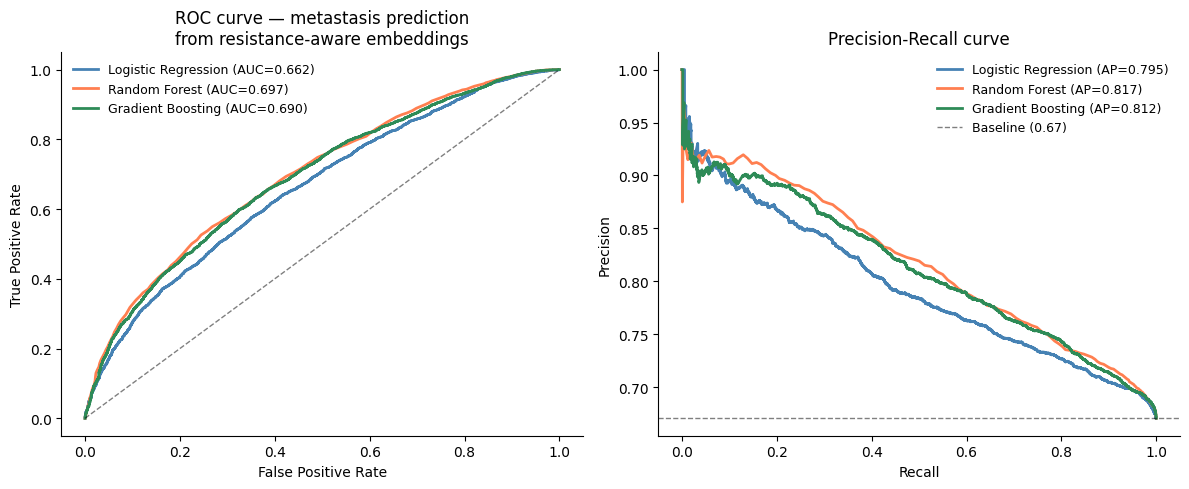

In [27]:
# ── Figure 1: ROC curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colours = ['steelblue', 'coral', 'seagreen']

for (name, res), colour in zip(results.items(), colours):
    fpr, tpr, _ = roc_curve(y, res['probs'])
    axes[0].plot(fpr, tpr, colour, lw=2,
                 label=f'{name} (AUC={res["auc"]:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve — metastasis prediction\nfrom resistance-aware embeddings')
axes[0].legend(fontsize=9, frameon=False)
axes[0].spines[['top','right']].set_visible(False)

# Precision-Recall
for (name, res), colour in zip(results.items(), colours):
    prec, rec, _ = precision_recall_curve(y, res['probs'])
    axes[1].plot(rec, prec, colour, lw=2,
                 label=f'{name} (AP={res["ap"]:.3f})')

baseline = y.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve')
axes[1].legend(fontsize=9, frameon=False)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 3 — Survival analysis by predicted risk

We use the best classifier to assign each TCGA patient a metastasis risk score.
Then we split patients into high/low risk (median threshold) and compare
Kaplan-Meier survival curves.

This is the key translational result: if high-risk embedding patients
have significantly worse OS, the latent space carries clinically meaningful signal.

In [28]:
# Use best model by AUC
best_name = max(results, key=lambda k: results[k]['auc'])
best_probs = results[best_name]['probs']
print(f'Best model: {best_name} (AUC={results[best_name]["auc"]:.3f})')

# Assign risk groups
risk_scores = pd.Series(best_probs, index=common, name='risk_score')
median_risk  = risk_scores.median()
risk_group   = (risk_scores >= median_risk).map({True: 'High risk', False: 'Low risk'})

# Align with survival data
surv = tcga_clin.loc[common, ['os_days', 'os_event', 'cancer_type']].copy()
surv['risk_group']  = risk_group
surv['risk_score']  = risk_scores
surv['os_days']     = pd.to_numeric(surv['os_days'],  errors='coerce')
surv['os_event']    = pd.to_numeric(surv['os_event'], errors='coerce')
surv = surv.dropna(subset=['os_days', 'os_event'])

print(f'Survival analysis samples: {len(surv)}')
print(surv['risk_group'].value_counts())

Best model: Random Forest (AUC=0.697)
Survival analysis samples: 10091
risk_group
High risk    5115
Low risk     4976
Name: count, dtype: int64


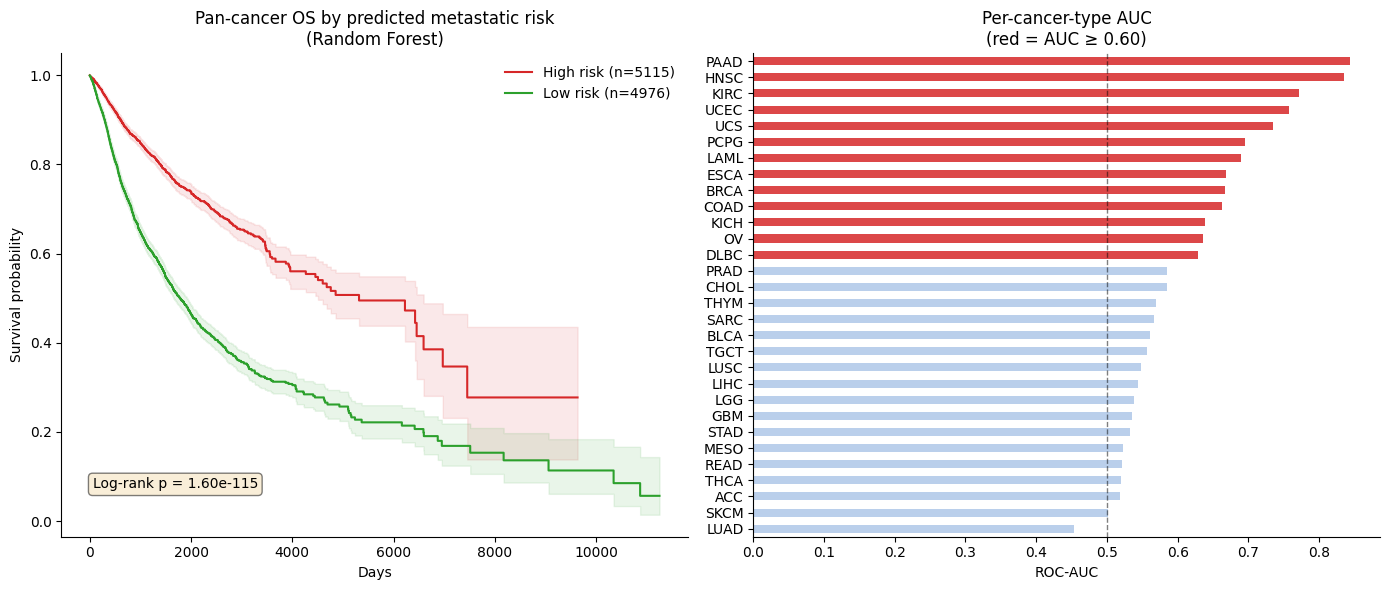

Log-rank p-value: 0.0000


In [29]:
# ── Figure 2: Kaplan-Meier by risk group ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pan-cancer KM
ax = axes[0]
kmf = KaplanMeierFitter()
colours = {'High risk': '#d62728', 'Low risk': '#2ca02c'}

for group, colour in colours.items():
    mask = surv['risk_group'] == group
    kmf.fit(
        surv.loc[mask, 'os_days'],
        surv.loc[mask, 'os_event'],
        label=f'{group} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, ci_alpha=0.1, color=colour)

# Log-rank test p-value
high = surv[surv['risk_group'] == 'High risk']
low  = surv[surv['risk_group'] == 'Low risk']
lr   = logrank_test(high['os_days'], low['os_days'],
                    high['os_event'], low['os_event'])
p_val = lr.p_value

ax.text(0.05, 0.1, f'Log-rank p = {p_val:.2e}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Days')
ax.set_ylabel('Survival probability')
ax.set_title(f'Pan-cancer OS by predicted metastatic risk\n({best_name})')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

# Per cancer type AUC bar chart
ax2 = axes[1]
ct_aucs = {}
for ct in surv['cancer_type'].dropna().unique():
    mask = (surv['cancer_type'] == ct)
    y_ct = y[surv.index.get_indexer(surv[mask].index)]
    p_ct = best_probs[surv.index.get_indexer(surv[mask].index)]
    if y_ct.sum() >= 5 and (y_ct == 0).sum() >= 5:
        try:
            ct_aucs[ct] = roc_auc_score(y_ct, p_ct)
        except Exception:
            pass

ct_auc_series = pd.Series(ct_aucs).sort_values(ascending=True)
colours_bar = ['#d62728' if v >= 0.6 else '#aec7e8' for v in ct_auc_series]
ct_auc_series.plot(kind='barh', ax=ax2, color=colours_bar, alpha=0.85)
ax2.axvline(0.5, color='k', linestyle='--', lw=1, alpha=0.5)
ax2.set_xlabel('ROC-AUC')
ax2.set_title('Per-cancer-type AUC\n(red = AUC ≥ 0.60)')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_survival_by_risk.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Log-rank p-value: {p_val:.4f}')

## Step 4 — Which latent dimensions drive metastasis prediction?

This is the interpretability step. We fit a logistic regression with L1 penalty
on the full dataset and inspect which of the 32 latent dimensions get non-zero
coefficients. Then we decode those dimensions back to gene space to give
them biological meaning.

In [30]:
# Fit L1 logistic regression on full labelled set
lr_l1 = LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                            max_iter=1000, random_state=42)
lr_l1.fit(X, y)

coef = pd.Series(
    lr_l1.coef_[0],
    index=[f'z{i}' for i in range(X.shape[1])]
).sort_values(key=abs, ascending=False)

print('Top latent dimensions for metastasis prediction:')
print(coef[coef != 0].head(15))

Top latent dimensions for metastasis prediction:
z20   -2.575421
z4    -1.196523
z10   -0.891327
z25    0.241471
z31   -0.236943
z3     0.189189
z27    0.167902
z15    0.040183
z19   -0.018648
dtype: float64


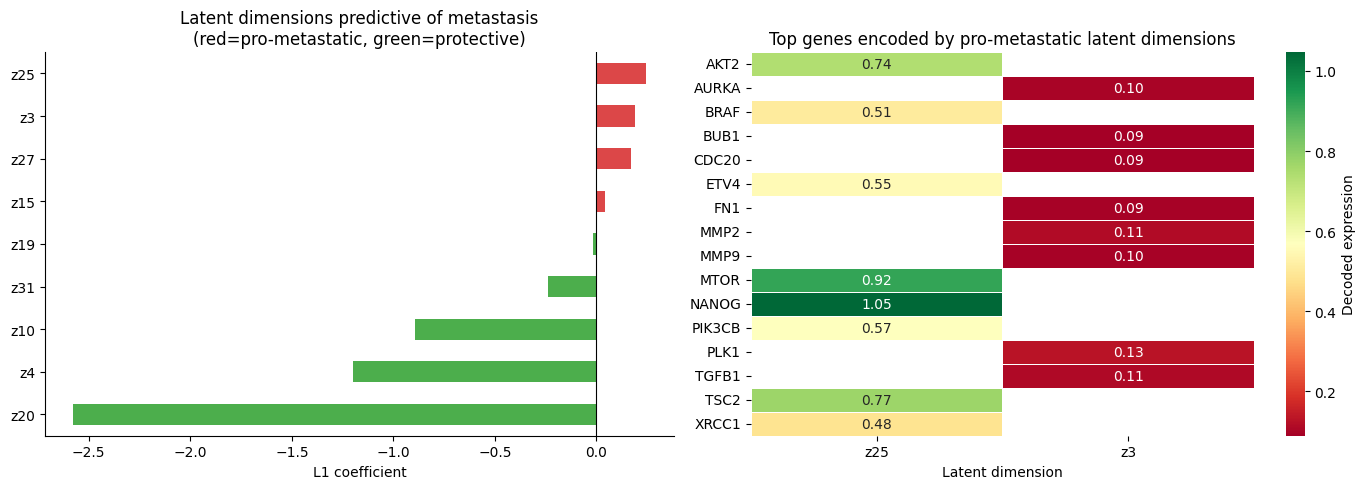

In [31]:
# ── Figure 3: Latent dimension importance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient plot
nonzero = coef[coef != 0].sort_values()
bar_colours = ['#d62728' if v > 0 else '#2ca02c' for v in nonzero]
nonzero.plot(kind='barh', ax=axes[0], color=bar_colours, alpha=0.85)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('L1 coefficient')
axes[0].set_title('Latent dimensions predictive of metastasis\n(red=pro-metastatic, green=protective)')
axes[0].spines[['top','right']].set_visible(False)

# Decode top dimensions back to gene space
# Load model and decode unit vectors along top dimensions
import torch
import sys

# Re-define VAE class (same as notebook 02)
class VAE(torch.nn.Module):
    def __init__(self, n_genes=97, latent_dim=32, hidden=64, dropout=0.1):
        super().__init__()
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(n_genes, hidden), torch.nn.LayerNorm(hidden),
            torch.nn.GELU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden, hidden), torch.nn.GELU(),
        )
        self.fc_mu      = torch.nn.Linear(hidden, latent_dim)
        self.fc_log_var = torch.nn.Linear(hidden, latent_dim)
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden), torch.nn.LayerNorm(hidden),
            torch.nn.GELU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden, n_genes),
        )
    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_log_var(h).clamp(-10,5)
    def decode(self, z): return self.dec(z)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.exp(0.5*lv)*torch.randn_like(mu)
        return self.decode(z), mu, lv

genes = pd.read_csv('data/shared_genes.csv', header=None)[0].tolist()
vae   = VAE(n_genes=len(genes), latent_dim=32)
vae.load_state_dict(torch.load('models/vae.pt', map_location='cpu'))
vae.eval()

# For each top latent dim, decode a unit vector and show gene loadings
top_dims = nonzero.abs().nlargest(6).index.tolist()
gene_loadings = {}

with torch.no_grad():
    for dim_name in top_dims:
        dim_idx = int(dim_name.replace('z',''))
        z = torch.zeros(1, 32)
        z[0, dim_idx] = 3.0  # probe with +3 SD in this dimension
        decoded = vae.decode(z).squeeze().numpy()
        gene_loadings[dim_name] = pd.Series(decoded, index=genes)

# Show top 5 genes per top 3 pro-metastatic dimensions
pro_met_dims = nonzero[nonzero > 0].nlargest(3).index.tolist()
loading_df = pd.DataFrame(
    {d: gene_loadings[d].nlargest(8) for d in pro_met_dims if d in gene_loadings}
)

sns.heatmap(
    loading_df, ax=axes[1], cmap='RdYlGn',
    cbar_kws={'label': 'Decoded expression'},
    linewidths=0.5, annot=True, fmt='.2f'
)
axes[1].set_title('Top genes encoded by pro-metastatic latent dimensions')
axes[1].set_xlabel('Latent dimension')

plt.tight_layout()
plt.savefig('figures/03_latent_dim_importance.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 5 — Save results summary

In [34]:
Path('results').mkdir(exist_ok=True)

In [36]:
# Classification report
best_preds = (results[best_name]['probs'] >= 0.5).astype(int)
report = classification_report(y, best_preds, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv('results/metastasis_classifier_report.csv')

# Summary table
summary = pd.DataFrame([
    {'model': name, 'auc': res['auc'], 'average_precision': res['ap']}
    for name, res in results.items()
])
summary.to_csv('results/model_comparison.csv', index=False)

# Risk scores per patient
surv.to_csv('results/patient_risk_scores.csv')

print('Results saved.')
print()
print('=' * 55)
print('PROJECT COMPLETE')
print('=' * 55)
print()
print('Figures:')
for f in sorted(Path('figures').glob('*.png')):
    print(f'  {f}')
print()
print('Results:')
for f in sorted(Path('results').glob('*.csv')):
    print(f'  {f}')
print()
print('Model summary:')
print(summary.to_string(index=False))
print()
print(f'Log-rank p-value (survival stratification): {p_val:.2e}')

Results saved.

PROJECT COMPLETE

Figures:
  figures/01_harmonisation_qc.png
  figures/02_training_curves.png
  figures/02_umap_cancer_type.png
  figures/02_umap_resistance.png
  figures/02_umap_resistance_ellipses.png
  figures/03_latent_dim_importance.png
  figures/03_roc_curve.png
  figures/03_survival_by_risk.png

Results:
  results/metastasis_classifier_report.csv
  results/model_comparison.csv
  results/patient_risk_scores.csv

Model summary:
              model      auc  average_precision
Logistic Regression 0.661561           0.794859
      Random Forest 0.697058           0.816526
  Gradient Boosting 0.689752           0.811582

Log-rank p-value (survival stratification): 1.60e-115
